In [3]:
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from pathlib import Path
from scipy.signal import find_peaks
import sys
sys.path.append('../')
from data.utils import get_path

In [5]:
data_path = os.path.join(get_path(), "/gpfs01/berens/user/sdamrich/data/graph_torus/3figures")

In [6]:
# takes 4 min to load
paths = sorted(Path(os.path.join(data_path, "data")).glob("s1*.jpg"))  # s1 images show yoda and bulldog s2 image show bulldog and rabbit

imgs = np.stack([
    np.array(Image.open(p).convert("RGB"))
    for p in paths
])
print(imgs.shape)

(8100, 240, 320, 3)


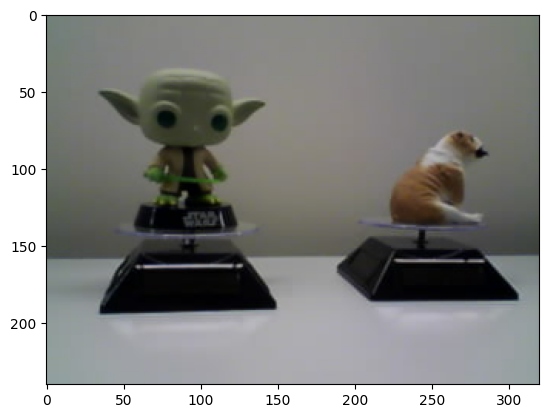

In [7]:
plt.imshow(imgs[0])

In [8]:
# get metadata

In [9]:
imgs_left = imgs[:, :, :160]
imgs_right = imgs[:, :, 160:]

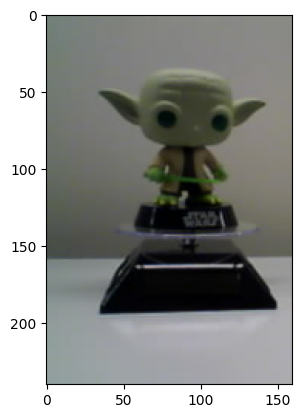

In [15]:
plt.imshow(imgs_left[0])

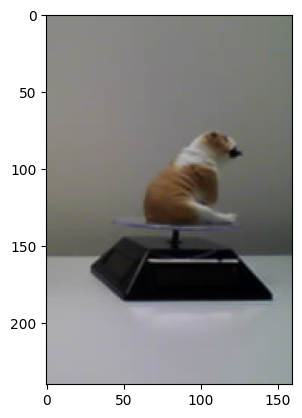

In [8]:
plt.imshow(imgs_right[0])

In [16]:
# difference from the first image, for illustration of the two rotation periods.
diff_left =  np.sqrt(((imgs_left - imgs_left[0][None])**2).sum(axis=tuple(range(1, imgs_left.ndim))))
diff_right = np.sqrt(((imgs_right- imgs_right[0][None])**2).sum(axis=tuple(range(1, imgs_left.ndim))))

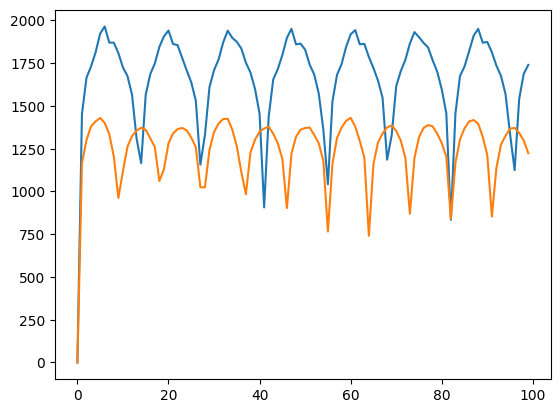

In [17]:
fig, ax = plt.subplots(1, 1)
ax.plot(diff_left[:100])
ax.plot(diff_right[:100])

In [18]:
def fundamental_freq(Y, thresh=0.2):
    """Fundamental temporal frequency of periodic projection signals Y (n_frames, n_proj).

    Takes the lowest prominent peak of the summed power spectrum instead of the
    global argmax: for a near-symmetric figurine (e.g. yoda) the 2nd harmonic
    dominates scalar signals like the diff to a reference frame.
    """
    n = len(Y)
    f = np.fft.rfftfreq(n)
    P = (np.abs(np.fft.rfft(Y - Y.mean(0), axis=0)) ** 2).sum(1)
    P[f < 2.0 / n] = 0.0  # drop DC / slow drift
    cand = np.flatnonzero(P > thresh * P.max())
    grp = [cand[0]]  # lowest contiguous peak group
    for c in cand[1:]:
        if c - grp[-1] <= 2:
            grp.append(c)
        else:
            break
    g = np.array(grp)
    return f[g[np.argmax(P[g])]]


def get_angle(x, f0=None, band=0.3, n_proj=8, seed=0):
    """Rotation angle per frame from an image time series x (n_frames, ...).

    Projects the frames onto a few random directions (a generic linear
    functional of the image has a clean fundamental component in the rotation
    angle), detects the fundamental frequency, band-passes the positive-frequency
    band around it, and reads the angle off the analytic signal. The projections
    are phase-aligned and averaged. Exact up to a global offset/sign as long as
    the rotation speed stays within the band.

    Returns (angle, f0): angles in [0, 2*pi) and the detected frequency.
    """
    X = x.reshape(len(x), -1).astype(np.float32)
    rng = np.random.default_rng(seed)
    Y = X @ rng.standard_normal((X.shape[1], n_proj)).astype(X.dtype)
    if f0 is None:
        f0 = fundamental_freq(Y)
    f = np.fft.fftfreq(len(Y))
    mask = (f > f0 * (1 - band)) & (f < f0 * (1 + band))
    Z = np.fft.ifft(2 * np.fft.fft(Y - Y.mean(0), axis=0) * mask[:, None], axis=0)
    zref = Z[:, np.argmax(np.abs(Z).mean(0))]
    zsum = np.zeros(len(Y), dtype=complex)
    for j in range(Z.shape[1]):
        rot = np.mean(Z[:, j] * np.conj(zref))
        zsum += Z[:, j] * np.conj(rot / max(abs(rot), 1e-12))
    return np.mod(np.angle(zsum), 2 * np.pi), f0

In [19]:
# alternative dip-based extraction, kept as a cross-check for the analytic method above
def refine_minima_parabolic(s, dip_idx):
    """
    Refine integer-valued minima locations to sub-sample positions
    using a quadratic fit through (i-1, i, i+1).
    """
    s = np.asarray(s, dtype=float)
    dip_idx = np.asarray(dip_idx, dtype=int)

    t_refined = dip_idx.astype(float).copy()

    valid = (dip_idx > 0) & (dip_idx < len(s) - 1)
    ii = dip_idx[valid]

    y1 = s[ii - 1]
    y2 = s[ii]
    y3 = s[ii + 1]

    denom = (y1 - 2 * y2 + y3)

    # vertex offset relative to center point i
    delta = np.zeros_like(y2, dtype=float)
    good = np.abs(denom) > 1e-12
    delta[good] = 0.5 * (y1[good] - y3[good]) / denom[good]

    # optional clipping for stability
    delta = np.clip(delta, -0.5, 0.5)

    t_refined[valid] = ii + delta
    return t_refined


def phase_from_refined_dips_fill_tail(t_dips, n):
    """
    Parameters
    ----------
    t_dips : array-like, shape (m,)
        Refined dip times, strictly increasing, floats allowed.
    n : int
        Number of samples / frames.

    Returns
    -------
    phase : (n,) ndarray
        Unwrapped phase.
    phase_mod : (n,) ndarray
        Phase modulo 2*pi in [0, 2*pi).
    """
    t_dips = np.asarray(t_dips, dtype=float)

    if t_dips.ndim != 1:
        raise ValueError("t_dips must be 1D.")
    if len(t_dips) < 2:
        raise ValueError("Need at least two dips.")
    if np.any(np.diff(t_dips) <= 0):
        raise ValueError("t_dips must be strictly increasing.")

    t = np.arange(n, dtype=float)
    phase = np.full(n, np.nan)
    two_pi = 2 * np.pi

    # interpolate on complete intervals [t0, t1)
    for k, (t0, t1) in enumerate(zip(t_dips[:-1], t_dips[1:])):
        mask = (t >= t0) & (t < t1)
        phase[mask] = two_pi * (k + (t[mask] - t0) / (t1 - t0))

    # extrapolate before first dip using first cycle length
    t0, t1 = t_dips[0], t_dips[1]
    L_first = t1 - t0
    mask_before = t < t0
    phase[mask_before] = two_pi * ((t[mask_before] - t0) / L_first)

    # extrapolate after last dip using penultimate cycle length
    t_prev, t_last = t_dips[-2], t_dips[-1]
    L_last = t_last - t_prev
    mask_after = t >= t_last
    phase[mask_after] = two_pi * ((len(t_dips) - 1) + (t[mask_after] - t_last) / L_last)

    phase_mod = np.mod(phase, two_pi)
    return phase, phase_mod


def get_phase(x, min_dist = 3):
    # get difference between first and all following frames
    diffs = np.sqrt(((x - x[0][None])**2).sum(axis=tuple(range(1, imgs_left.ndim))))

    # extract dip locations, which correspond for a full period
    dips, _ = find_peaks(-diffs, distance=min_dist, prominence=0.01* np.ptp(diffs))

    # refine the dip location
    t_dips = refine_minima_parabolic(diffs, dip_idx= np.concatenate([[0], dips]))

    # return the phase modulo 2*pi as an angle
    _, phase_mod = phase_from_refined_dips_fill_tail(t_dips, n=len(imgs))
    return phase_mod

In [20]:
angle_left, f0_left = get_angle(imgs_left)
angle_right, f0_right = get_angle(imgs_right)
print(f"detected periods: left {1/f0_left:.1f} frames/rev, right {1/f0_right:.1f} frames/rev")

phases = np.stack([angle_left, angle_right], -1)  # angles in [0, 2*pi)
np.save(os.path.join(data_path, "phases.npy"), phases)

detected periods: left 12.2 frames/rev, right 9.0 frames/rev


In [21]:
# cross-check: dip-based angles should agree with the analytic ones up to a global
# offset/sign (min_dist=8 makes find_peaks skip yoda's second dip per revolution)
phase_left_dips = get_phase(imgs_left, min_dist=8)
phase_right_dips = get_phase(imgs_right, min_dist=5)


def circ_agreement(t1, t2):
    z1, z2 = np.exp(1j * t1), np.exp(1j * t2)
    return max(abs(np.mean(z1 * np.conj(z2))), abs(np.mean(z1 * z2)))


print(f"dip vs analytic agreement: left {circ_agreement(phase_left_dips, angle_left):.3f}, "
      f"right {circ_agreement(phase_right_dips, angle_right):.3f}")

dip vs analytic agreement: left 0.999, right 0.992


In [22]:
# Visualisations

In [23]:
imgs_flat = imgs.reshape(len(imgs), -1)

# fixed random_state: the randomized SVD is otherwise nondeterministic and rotates
# near-degenerate PCs between runs, changing e.g. pca[:, :5] and its distances
pca_embedder = PCA(n_components=50, svd_solver="randomized", random_state=0)
pca = pca_embedder.fit_transform(imgs_flat)

In [24]:
pca.shape

(8100, 50)

In [25]:
np.save(os.path.join(data_path, "yoda_bulldog_pca50.npy"), np.array(pca))

In [30]:
umap_embedding = umap.UMAP(n_components=3, min_dist=0.8).fit_transform(pca)

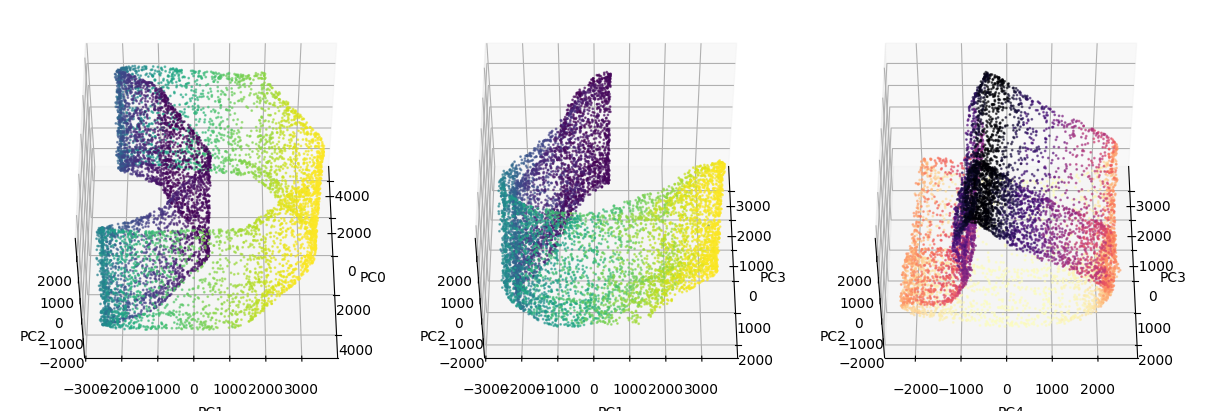

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(12, 7), subplot_kw={"projection": "3d"}, constrained_layout=True)

base_elev = 50
base_azim = 0  # choose what looks good for panel 0


cmaps = ["viridis", "viridis", "magma"]
color = [np.sin(phases[:, 0]), np.sin(phases[:, 0]), np.sin(phases[:, 1])]

for i in range(3):

    ax[i].scatter(
        *np.roll(pca[:, i:i+3], i ,axis=1).T,
        c=color[i], #np.arange(len(imgs)),
        s=1,          # marker size
        alpha=0.6,
        cmap=cmaps[i]
    )
    ax[i].view_init(elev=base_elev, azim=base_azim )
    pc_order = np.roll(np.arange(i, i+3),i)
    ax[i].set_xlabel(f"PC{pc_order[0]}")
    ax[i].set_ylabel(f"PC{pc_order[1]}")
    ax[i].set_zlabel(f"PC{pc_order[2]}")

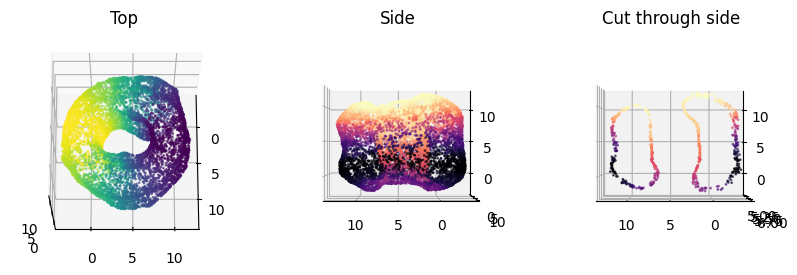

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6), subplot_kw={"projection": "3d"})

elevs = [70, 0, 0]
azims = [0, 90, 90]

labels = ["Top", "Side", "Cut through side"]

cmaps = ["viridis", "magma", "magma"]
color = [np.sin(phases[:, 0]), np.sin(phases[:, 1]), np.sin(phases[:, 1])]

for i in range(3):

    mask = np.ones(len(umap_embedding), dtype=bool)
    if i > 1:
        mask = (umap_embedding[:, 1] >5) * (umap_embedding[:, 1] < 6)

    ax[i].scatter(
        *umap_embedding[mask].T,
        c=color[i][mask],
        s=1,          # marker size
        alpha=0.6,
        cmap=cmaps[i]
    )
    ax[i].view_init(elev=elevs[i], azim=azims[i])
    ax[i].set_title(labels[i])